# Wedge
This notebook cover the mapting of a wedge with its internal angle $\alpha$ into the half-plane.

## The mapping
Th emapping of a wedge to a  helf-plaine is given by
\begin{equation*}
    z = \xi^{\pi/\alpha}
\end{equation*}

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from conformal_mappings.mappings import z_to_xi_wedge, xi_to_z_wedge
from conformal_mappings.elements import omega_uni_flow
from conformal_mappings.plotter import contour_flow_net

## Uniform flow along the wedge
We consider the case of uniform flow along the boundary of the wedge.

In [28]:
# Varialbes
w = 1 + 0j
alpha = np.pi/6

# Omega function
omega_func = lambda z: omega_uni_flow(z, w)



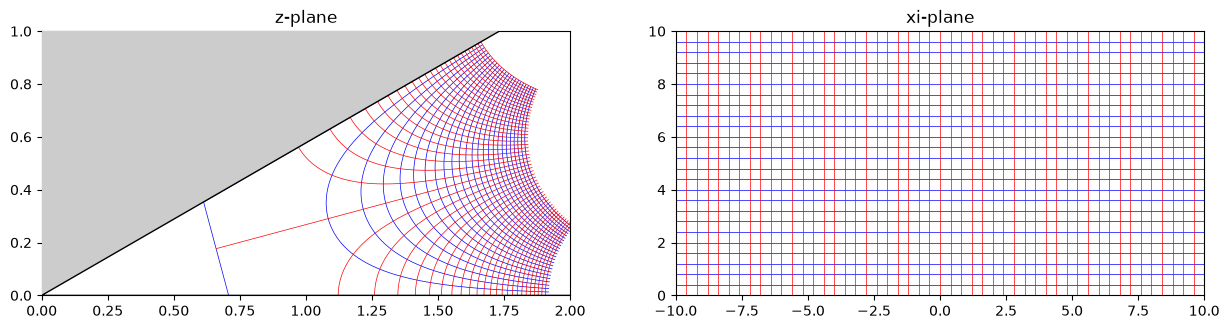

In [29]:
fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-50, 50),
    (0, 50),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_wedge(chi, alpha),
    ax=ax[0]
)
xi = np.concatenate([
    np.linspace(-80, -1e-3, 20),
    np.linspace(-1e-8, 1e-8, 15),
    np.linspace(1e-3, 80, 15)
]) + 0j
z = xi_to_z_wedge(xi, alpha)
z[0] = -1 + z[0].imag*1.1j
ax[0].fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 1)
ax[0].set_title(r"$z$-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title(r"$\xi$-plane")
ax[1].set_aspect('equal')


## A well near an impermeable wall
We consider the case of a well near an impreamable wall along the boundary of the wedge.

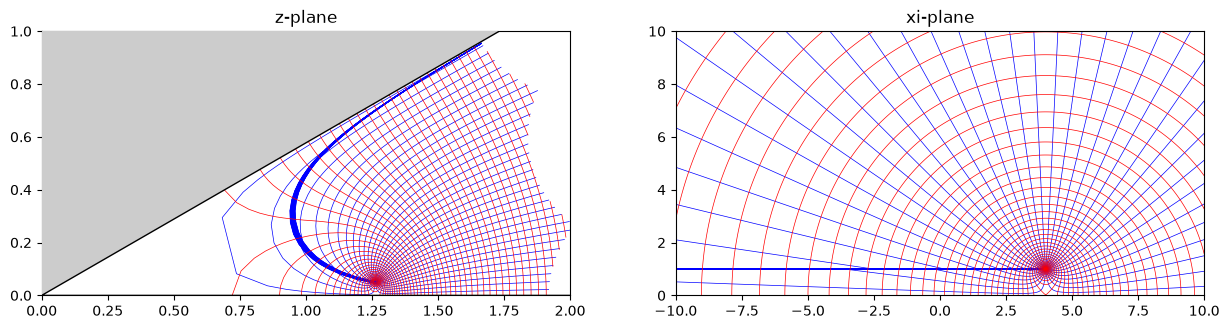

In [30]:
# Varialbes
from conformal_mappings.elements import omega_well


q = 1
zw = 4 + 1j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) + omega_well(z, q, lambda z: z-np.conj(zw))

fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-50, 50),
    (0, 50),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_wedge(chi, alpha),
    ax=ax[0]
)
xi = np.concatenate([
    np.linspace(-80, -1e-3, 20),
    np.linspace(-1e-8, 1e-8, 15),
    np.linspace(1e-3, 80, 15)
]) + 0j
z = xi_to_z_wedge(xi, alpha)
z[0] = -1 + z[0].imag*1.1j
ax[0].fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 1)
ax[0].set_title(r"$z$-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title(r"$\xi$-plane")
ax[1].set_aspect('equal')


## A well near a smooth curved impermeable wall
We can also make the wedge have a smooth tip by offsetting the mirror a small amount.

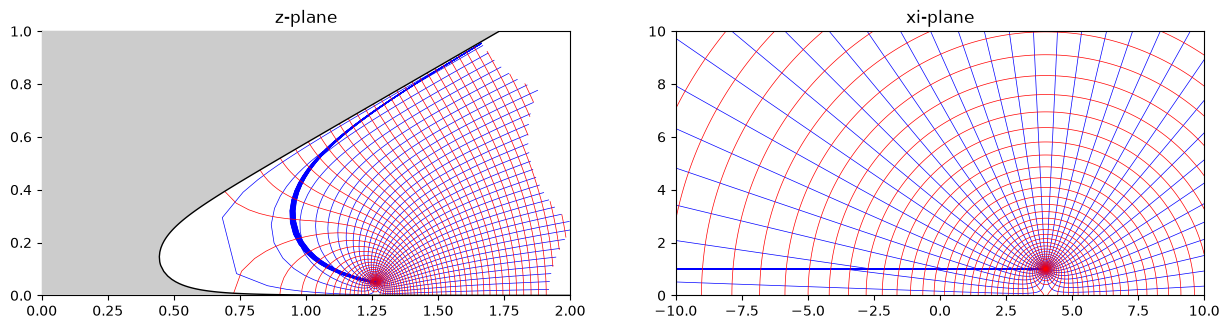

In [31]:
zw = 4 + 1j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) + omega_well(z, q, lambda z: z-(np.conj(zw)+.01j))

fig, ax = plt.subplots(1,2,figsize=(15, 7))
contour_flow_net(
    (-50, 50),
    (0, 50),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_wedge(chi, alpha),
    ax=ax[0]
)
# Refine the mapped boundary near the origin while keeping the far-field coverage
xi = np.concatenate([
    np.linspace(-80, -5, 1500),
    np.linspace(-5, -1e-3, 2000),
    np.linspace(-1e-3, 1e-3, 1500),
    np.linspace(1e-3, 5, 1500),
    np.linspace(5, 80, 1500)
]) + 0.01j
z = xi_to_z_wedge(xi, alpha)
z[0] = -1 + z[0].imag*1.1j
ax[0].fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[0].set_xlim(0, 2)
ax[0].set_ylim(0, 1)
ax[0].set_title(r"$z$-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].set_xlim(-10, 10)
ax[1].set_ylim(0, 10)
ax[1].set_title(r"$\xi$-plane")
ax[1].set_aspect('equal')


## Mapping of the outside of the wedge
The region exterior to the wedge has opening angle $2\pi-\alpha$, so the same construction gives
\begin{equation*}
    z = \chi^{(2\pi-\alpha)/\pi}
\end{equation*}
or equivalently
\begin{equation*}
    \chi = z^{\pi/(2\pi-\alpha)}.
\end{equation*}
This maps the outside of the wedge to the upper half-plane.

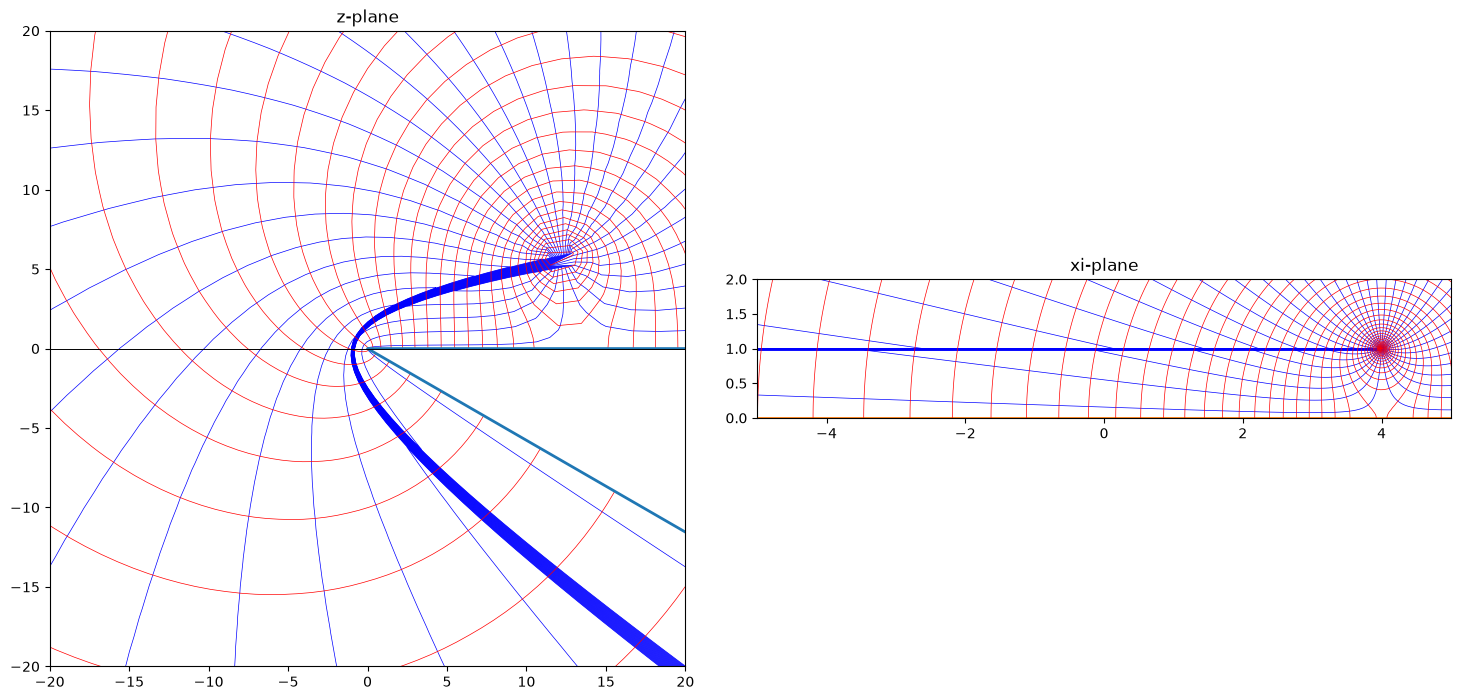

In [32]:
alpha_out = 2 * np.pi - alpha
xi = np.concatenate([
    np.linspace(-80, -1e-3, 100),
    np.linspace(-1e-8, 1e-8, 100),
    np.linspace(1e-3, 80, 100)
]) + 0j
z = xi_to_z_wedge(xi, alpha_out)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
contour_flow_net(
    (-50, 50),
    (0, 50),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_z_wedge(chi, alpha_out),
    ax=ax[0]
)
ax[0].plot(z.real, z.imag, color="C0", lw=2)
ax[0].set_title(r"$z$-plane")
ax[0].set_xlim(-20, 20)
ax[0].set_ylim(-20, 20)
ax[0].set_aspect("equal")
ax[0].axhline(0, color="k", lw=0.7)

ax[1].plot(xi.real, xi.imag, color="C1", lw=2)
contour_flow_net(
    (-10,10),
    (0, 10),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].axhline(0, color="k", lw=0.7)
ax[1].set_title(r"$\xi$-plane")
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(0, 2)
ax[1].set_aspect("equal")
fig.tight_layout()